# **Machine Learning Wage Prediction**
Predicting income using demographic and human capital variables

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load data
df = pd.read_parquet("acs_cleaned.parquet")

df = df.rename(columns={
    "Log Income": "Log_Income",
    "Income (2024 Dollars)": "Income_2024",
    "Education Group": "Education_Group"
})

In [3]:
# Select features
features = [
    "Age",
    "Sex",
    "Education_Group",
    "Demographic",
    "State",
    "Hours Worked"
]

target = "Log_Income"

df_ml = df[features + [target]].dropna()

In [4]:
# Sample data
df_ml = df_ml.sample(300000, random_state=42)

In [5]:
# Train/Test Split
X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Preprocessing
categorical = ["Sex","Education_Group","Demographic","State"]
numeric = ["Age","Hours Worked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)

In [7]:
# Random Forest Model
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
# Evaluate Model
pred = model.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R²: 0.2851916808894366
MAE: 0.4238822836373863


In [9]:
# Feature importance
rf = model.named_steps["rf"]

feature_names = model.named_steps["prep"].get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.head(15)

cat__Education_Group_Masters or Doctorate    0.204292
num__Age                                     0.169698
cat__Education_Group_Bachelor's              0.162949
num__Hours Worked                            0.121679
cat__Sex_Female                              0.074782
cat__Sex_Male                                0.065228
cat__Demographic_White                       0.035602
cat__Education_Group_Some College            0.018767
cat__Education_Group_HS or Less              0.015977
cat__State_California                        0.015430
cat__State_New Jersey                        0.008779
cat__Demographic_Asian                       0.007762
cat__State_New York                          0.007620
cat__Demographic_Black                       0.006597
cat__Demographic_Hispanic                    0.006054
dtype: float64

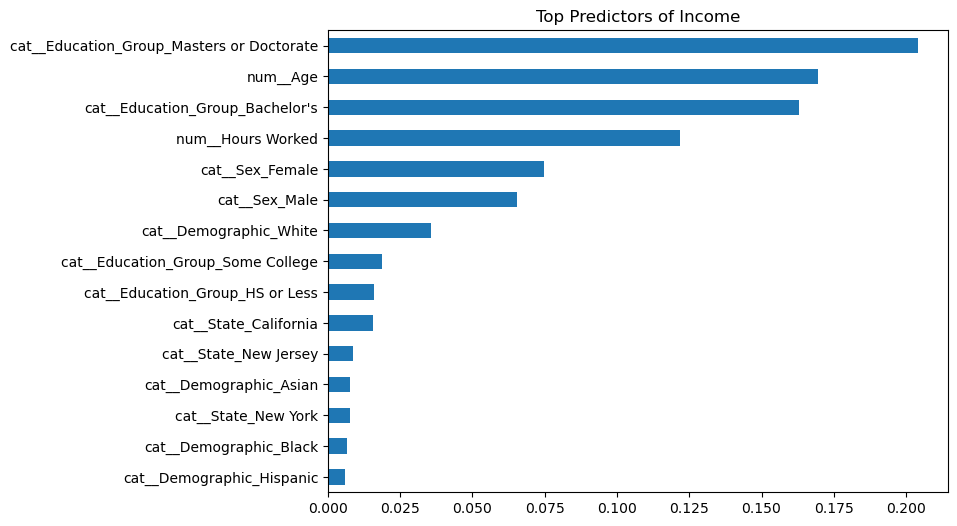

In [10]:
import matplotlib.pyplot as plt

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Predictors of Income")
plt.show()